## DEMO1 EDA 추가 검증

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root():
    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "models").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate

    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")


PROJECT_ROOT = find_project_root()

DATA_PATH = (
    PROJECT_ROOT
    / "models"
    / "ML"
    / "used_data"
    / "weekly_next_week_with_vle_enhanced.csv"
)

OOF_PATH = (
    PROJECT_ROOT
    / "models"
    / "ML"
    / "catboost_weekly_next_week_oof_predictions.csv"
)

print("프로젝트 위치:", PROJECT_ROOT)
print("학습 데이터 존재:", DATA_PATH.exists())
print("CatBoost OOF 존재:", OOF_PATH.exists())

data_header = pd.read_csv(DATA_PATH, nrows=0)
oof_header = pd.read_csv(OOF_PATH, nrows=0)

print("학습 데이터 전체 컬럼:", len(data_header.columns))
print("모델 입력 Feature:", len(data_header.columns) - 2)
print("OOF 컬럼:", oof_header.columns.tolist())

프로젝트 위치: /Users/kyungduck/Desktop/SKN_AI/SKAI 2차 프로젝트
학습 데이터 존재: True
CatBoost OOF 존재: True
학습 데이터 전체 컬럼: 126
모델 입력 Feature: 124
OOF 컬럼: ['code_module', 'code_presentation', 'id_student', 'prediction_week', 'target_next_week_withdrawn', 'catboost_oof_probability']


In [2]:
# Demo1 주간 EDA에 필요한 핵심 컬럼만 불러오기

EDA_COLS = [
    # 식별·시간 기준
    "code_module",
    "code_presentation",
    "id_student",
    "prediction_week",
    "cutoff_day",
    "module_presentation_length",

    # 학생 특성
    "gender",
    "age_band",
    "highest_education",

    # 다음 주 이탈 Target
    "target_next_week_withdrawn",

    # 현재 주 활동
    "current_total_clicks",
    "current_active_days",
    "current_unique_sites",
    "current_activity_type_count",
    "current_has_vle_record",
    "current_no_activity",

    # 직전 주 대비 변화
    "previous_total_clicks",
    "click_change",
    "click_change_rate",
    "weeks_since_last_activity",

    # 해당 시점까지 누적 활동
    "vle_cum_total_clicks",
    "vle_cum_active_days",
    "vle_cum_unique_sites",
    "cum_unique_site_week_count",

    # 활동 유형별 누적 클릭
    "cum_forumng_clicks",
    "cum_quiz_clicks",
    "cum_oucontent_clicks",
    "cum_resource_clicks",
    "cum_other_clicks",

    # 평가 행동
    "assessment_due_count",
    "assessment_submitted_due_count",
    "assessment_missing_due_count",
    "assessment_late_count",
    "assessment_submission_rate",
    "assessment_mean_score",
]

eda = pd.read_csv(
    DATA_PATH,
    usecols=EDA_COLS,
    low_memory=False
)

# 반복되는 문자열은 category로 바꿔 메모리 절약
category_cols = [
    "code_module",
    "code_presentation",
    "gender",
    "age_band",
    "highest_education",
]

for col in category_cols:
    eda[col] = eda[col].astype("category")

KEY_COLS = [
    "code_module",
    "code_presentation",
    "id_student",
    "prediction_week",
]

print("EDA 데이터 크기:", eda.shape)
print(
    "메모리 사용량:",
    f"{eda.memory_usage(deep=True).sum() / 1024**2:,.1f} MB"
)
print("학생 수:", eda["id_student"].nunique())
print("예측 주차:", sorted(eda["prediction_week"].unique()))
print("키 중복:", eda.duplicated(KEY_COLS).sum())

print("\nTarget 분포:")
print(eda["target_next_week_withdrawn"].value_counts())

print(
    "\n다음 주 이탈률:",
    f"{eda['target_next_week_withdrawn'].mean():.4%}"
)

display(eda.head())

EDA 데이터 크기: (895005, 35)
메모리 사용량: 209.1 MB
학생 수: 26045
예측 주차: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38)]
키 중복: 0

Target 분포:
target_next_week_withdrawn
0    888333
1      6672
Name: count, dtype: int64

다음 주 이탈률: 0.7455%


,code_module,code_presentation,id_student,prediction_week,cutoff_day,module_presentation_length,gender,highest_education,age_band,assessment_due_count,...,previous_total_clicks,weeks_since_last_activity,current_no_activity,click_change,click_change_rate,cum_forumng_clicks,cum_quiz_clicks,cum_oucontent_clicks,cum_resource_clicks,cum_other_clicks
0,AAA,2013J,11391,1,6,268,M,HE Qualification,55<=,0.0,...,0.0,0.0,0,183.0,0.00000,18.0,0.0,125.0,8.0,32.0
1,AAA,2013J,11391,2,13,268,M,HE Qualification,55<=,0.0,...,183.0,0.0,0,-163.0,-0.89071,18.0,0.0,143.0,8.0,34.0
2,AAA,2013J,11391,3,20,268,M,HE Qualification,55<=,1.0,...,20.0,0.0,0,80.0,4.00000,53.0,0.0,195.0,9.0,46.0
3,AAA,2013J,11391,4,27,268,M,HE Qualification,55<=,1.0,...,100.0,1.0,1,-100.0,-1.00000,53.0,0.0,195.0,9.0,46.0
4,AAA,2013J,11391,5,34,268,M,HE Qualification,55<=,1.0,...,0.0,0.0,0,26.0,0.00000,55.0,0.0,208.0,9.0,57.0


===== 다음 주 이탈 건수가 많은 주차 =====


,prediction_week,at_risk_count,next_week_withdrawal_count,next_week_withdrawal_rate_pct
0,1,29018,1068,3.680
2,3,27801,360,1.295
3,4,27449,303,1.104
6,7,26692,256,0.959
5,6,26936,246,0.913
7,8,26437,230,0.870
8,9,26208,220,0.839
13,14,25268,218,0.863
4,5,27149,216,0.796
1,2,27984,214,0.765



===== 다음 주 이탈률이 높은 주차 =====


,prediction_week,at_risk_count,next_week_withdrawal_count,next_week_withdrawal_rate_pct
0,1,29018,1068,3.680
2,3,27801,360,1.295
3,4,27449,303,1.104
6,7,26692,256,0.959
5,6,26936,246,0.913
7,8,26437,230,0.870
21,22,23878,207,0.867
13,14,25268,218,0.863
8,9,26208,220,0.839
12,13,25472,204,0.801


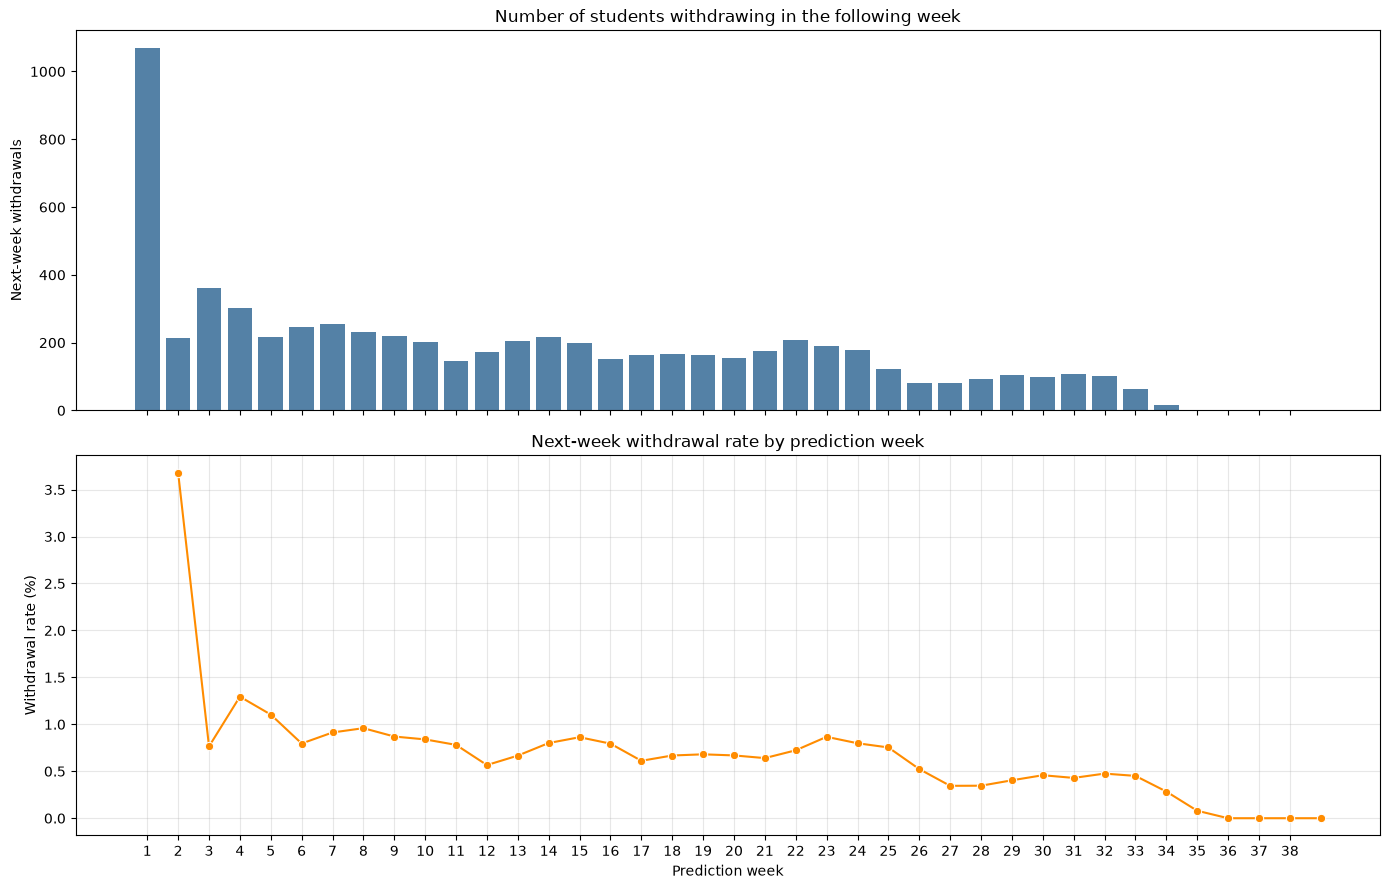

In [3]:
# 주차별 다음 주 이탈 현황

TARGET_COL = "target_next_week_withdrawn"

weekly_target = (
    eda
    .groupby("prediction_week", as_index=False, observed=True)
    .agg(
        at_risk_count=("id_student", "size"),
        next_week_withdrawal_count=(TARGET_COL, "sum")
    )
)

weekly_target["next_week_withdrawal_rate_pct"] = (
    weekly_target["next_week_withdrawal_count"]
    / weekly_target["at_risk_count"]
    * 100
)

print("===== 다음 주 이탈 건수가 많은 주차 =====")
display(
    weekly_target
    .sort_values(
        "next_week_withdrawal_count",
        ascending=False
    )
    .head(10)
    .round(3)
)

print("\n===== 다음 주 이탈률이 높은 주차 =====")
display(
    weekly_target
    .sort_values(
        "next_week_withdrawal_rate_pct",
        ascending=False
    )
    .head(10)
    .round(3)
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True
)

# 다음 주 실제 이탈 건수
sns.barplot(
    data=weekly_target,
    x="prediction_week",
    y="next_week_withdrawal_count",
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title(
    "Number of students withdrawing in the following week"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Next-week withdrawals")

# 다음 주 조건부 이탈률
sns.lineplot(
    data=weekly_target,
    x="prediction_week",
    y="next_week_withdrawal_rate_pct",
    marker="o",
    color="darkorange",
    ax=axes[1]
)

axes[1].set_title(
    "Next-week withdrawal rate by prediction week"
)
axes[1].set_xlabel("Prediction week")
axes[1].set_ylabel("Withdrawal rate (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 주차별 다음 주 이탈 현황

1주차까지의 데이터를 이용해 2주차 이탈을 예측할 때 다음 주 이탈자는
1,068명, 조건부 이탈률은 약 3.68%로 가장 높았다.

초기 주차에 이탈 위험이 집중되지만 이후 주차에도 이탈이 계속 발생하므로,
특정 한 주차만 예측하기보다 매주 최신 학습행동을 반영하여 다음 주 이탈
위험을 반복적으로 예측하는 조기경보 방식이 필요하다.

단, 후반 주차는 과목별 운영 기간과 관찰 종료 시점이 다르므로 단순 이탈률
비교 시 관찰 대상 수를 함께 고려해야 한다.

===== 과목별 다음 주 이탈률 상위 구간 =====


,code_module,prediction_week,at_risk_count,next_week_withdrawal_count,next_week_withdrawal_rate_pct
76,CCC,1,3860,219,5.674
189,FFF,1,6983,297,4.253
151,EEE,1,2675,106,3.963
38,BBB,1,6755,248,3.671
79,CCC,4,3493,122,3.493
114,DDD,1,5565,182,3.270
78,CCC,3,3571,80,2.240
90,CCC,15,2956,60,2.030
77,CCC,2,3643,73,2.004
84,CCC,9,3171,60,1.892


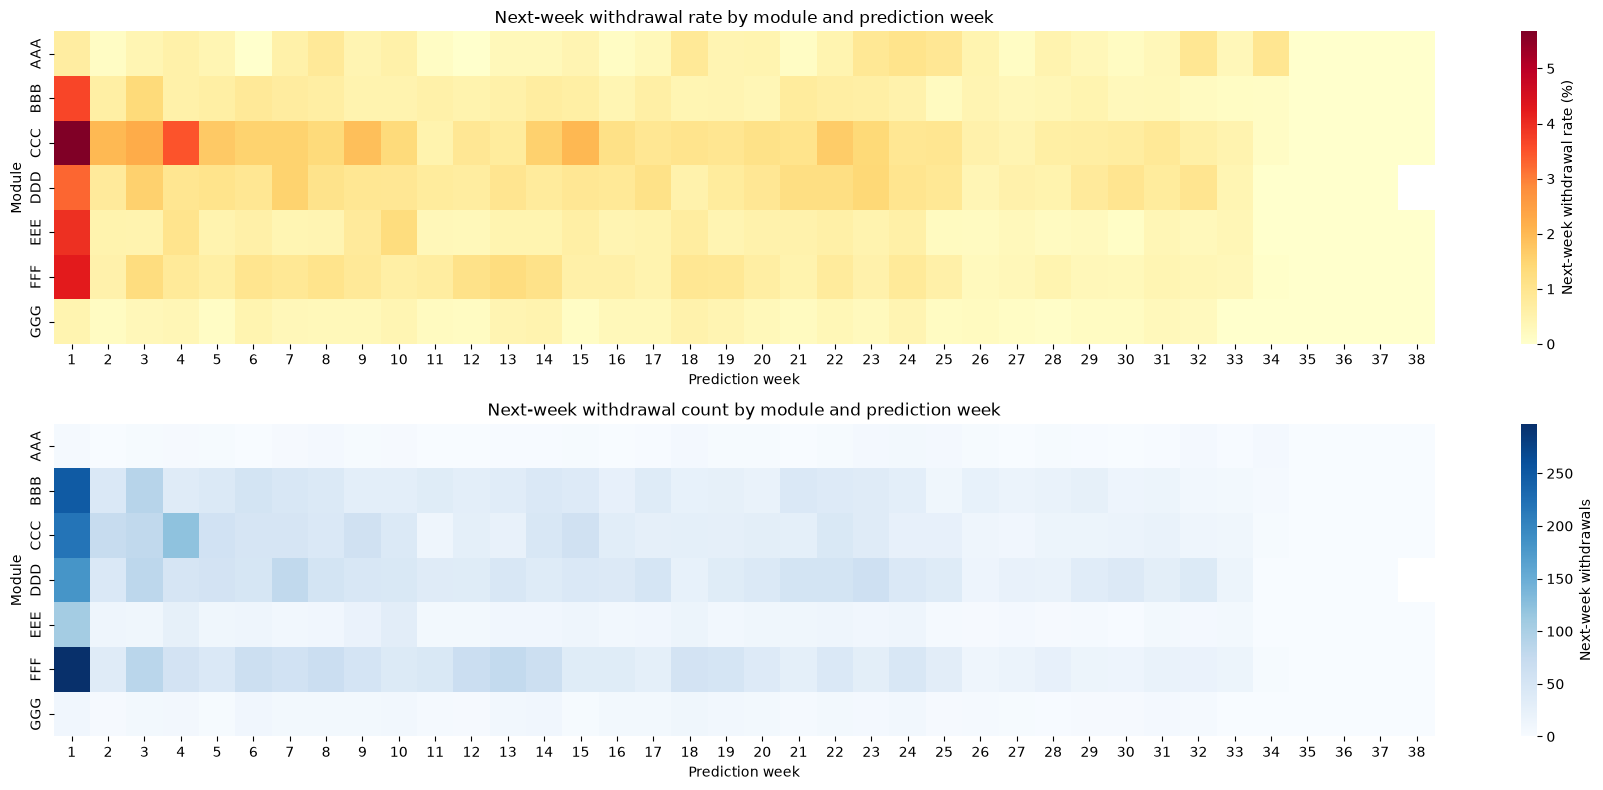

In [4]:
# 과목별·예측 주차별 다음 주 이탈 현황

module_week_target = (
    eda
    .groupby(
        ["code_module", "prediction_week"],
        as_index=False,
        observed=True
    )
    .agg(
        at_risk_count=("id_student", "size"),
        next_week_withdrawal_count=(
            TARGET_COL,
            "sum"
        )
    )
)

module_week_target["next_week_withdrawal_rate_pct"] = (
    module_week_target["next_week_withdrawal_count"]
    / module_week_target["at_risk_count"]
    * 100
)

# 표본이 너무 적은 후반 주차의 과도한 비율을 방지
stable_module_week = module_week_target.loc[
    module_week_target["at_risk_count"] >= 100
].copy()

print("===== 과목별 다음 주 이탈률 상위 구간 =====")
display(
    stable_module_week
    .sort_values(
        [
            "next_week_withdrawal_rate_pct",
            "next_week_withdrawal_count"
        ],
        ascending=False
    )
    .head(20)
    .round(3)
)

rate_pivot = stable_module_week.pivot(
    index="code_module",
    columns="prediction_week",
    values="next_week_withdrawal_rate_pct"
)

count_pivot = stable_module_week.pivot(
    index="code_module",
    columns="prediction_week",
    values="next_week_withdrawal_count"
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(18, 8)
)

sns.heatmap(
    rate_pivot,
    cmap="YlOrRd",
    mask=rate_pivot.isna(),
    ax=axes[0],
    cbar_kws={"label": "Next-week withdrawal rate (%)"}
)
axes[0].set_title(
    "Next-week withdrawal rate by module and prediction week"
)
axes[0].set_xlabel("Prediction week")
axes[0].set_ylabel("Module")

sns.heatmap(
    count_pivot,
    cmap="Blues",
    mask=count_pivot.isna(),
    ax=axes[1],
    cbar_kws={"label": "Next-week withdrawals"}
)
axes[1].set_title(
    "Next-week withdrawal count by module and prediction week"
)
axes[1].set_xlabel("Prediction week")
axes[1].set_ylabel("Module")

plt.tight_layout()
plt.show()

,prediction_week,target_label,student_course_count,median_current_clicks,median_current_active_days,median_current_unique_sites,no_activity_rate,median_click_change,median_weeks_since_last_activity,no_activity_rate_pct
0,1,Next-week withdrawn,1068,1.0,1.0,1.0,0.49,1.0,0.0,49.34
1,1,Non-withdrawn,27950,33.0,2.0,8.0,0.19,33.0,0.0,18.69
2,2,Next-week withdrawn,214,7.0,1.0,2.5,0.36,-1.0,0.0,36.45
3,2,Non-withdrawn,27770,30.0,2.0,6.0,0.20,0.0,0.0,19.56
4,3,Next-week withdrawn,360,1.0,1.0,1.0,0.47,0.0,0.0,46.67
5,3,Non-withdrawn,27441,45.0,3.0,7.0,0.16,3.0,0.0,16.12
6,4,Next-week withdrawn,303,1.0,1.0,1.0,0.46,-6.0,0.0,45.87
7,4,Non-withdrawn,27146,25.0,2.0,6.0,0.21,-6.0,0.0,20.91
14,8,Next-week withdrawn,230,0.0,0.0,0.0,0.63,0.0,1.0,62.61
15,8,Non-withdrawn,26207,20.0,2.0,5.0,0.25,0.0,0.0,25.31


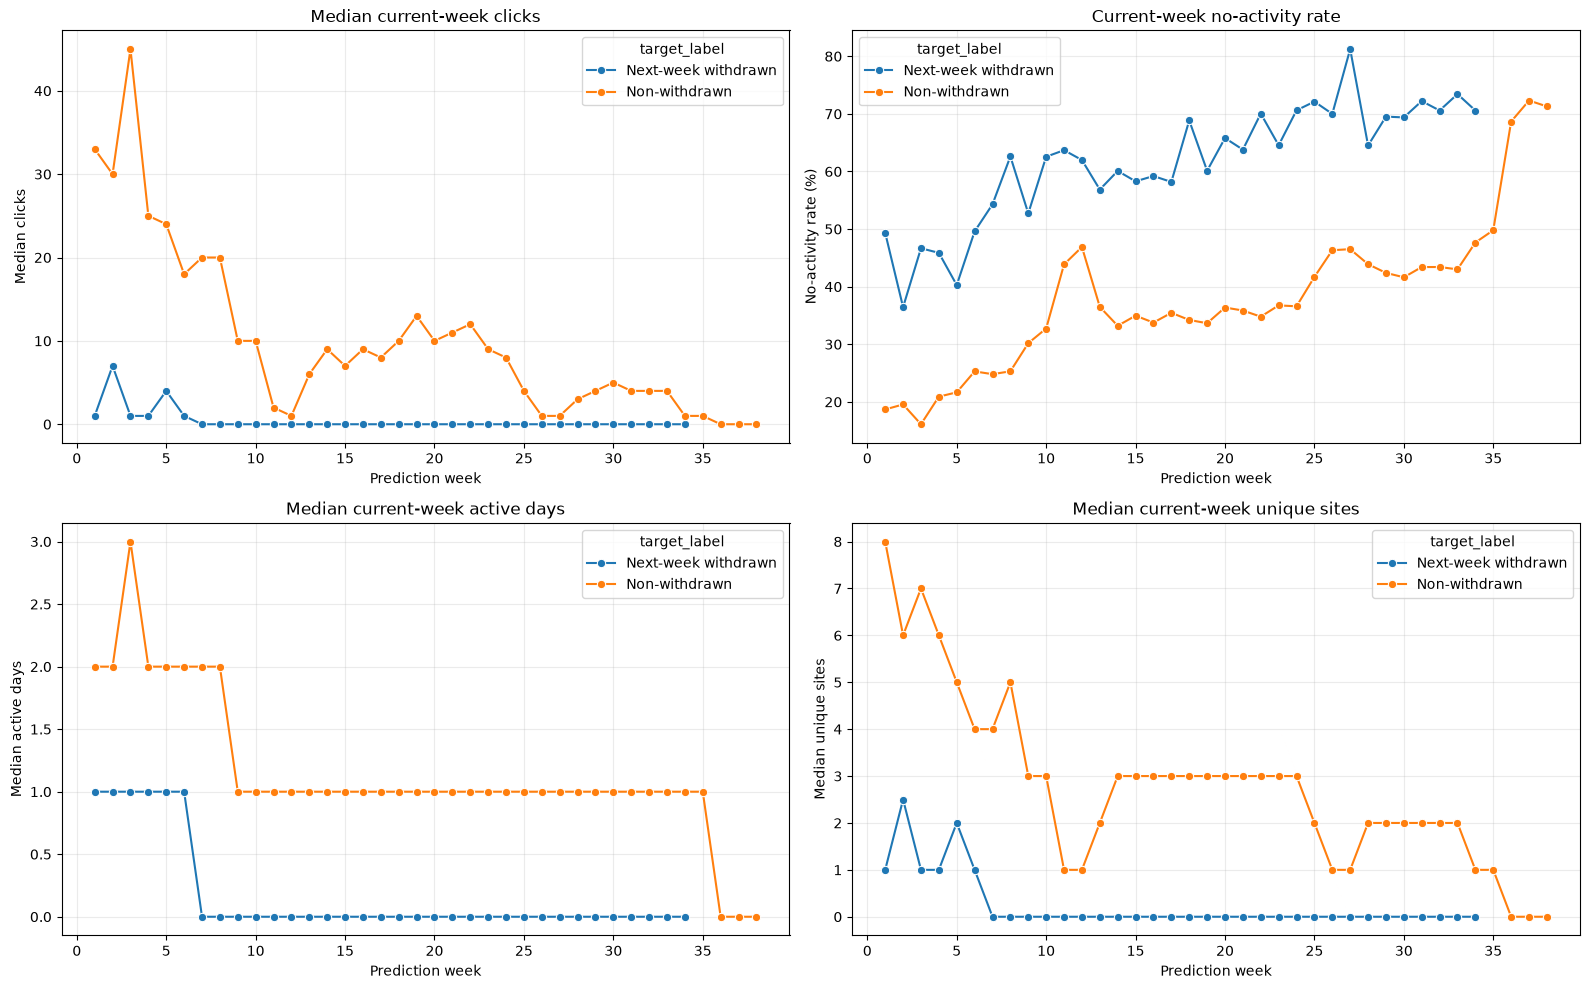

In [5]:
# 다음 주 이탈 여부에 따른 현재 주 학습행동 비교

behavior_summary = (
    eda
    .assign(
        target_label=np.where(
            eda[TARGET_COL].eq(1),
            "Next-week withdrawn",
            "Non-withdrawn"
        )
    )
    .groupby(
        ["prediction_week", "target_label"],
        as_index=False,
        observed=True
    )
    .agg(
        student_course_count=("id_student", "size"),

        median_current_clicks=(
            "current_total_clicks",
            "median"
        ),
        median_current_active_days=(
            "current_active_days",
            "median"
        ),
        median_current_unique_sites=(
            "current_unique_sites",
            "median"
        ),
        no_activity_rate=(
            "current_no_activity",
            "mean"
        ),
        median_click_change=(
            "click_change",
            "median"
        ),
        median_weeks_since_last_activity=(
            "weeks_since_last_activity",
            "median"
        )
    )
)

behavior_summary["no_activity_rate_pct"] = (
    behavior_summary["no_activity_rate"] * 100
)

display(
    behavior_summary.loc[
        behavior_summary["prediction_week"].isin(
            [1, 2, 3, 4, 8, 12, 16, 20]
        )
    ].round(2)
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

sns.lineplot(
    data=behavior_summary,
    x="prediction_week",
    y="median_current_clicks",
    hue="target_label",
    marker="o",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Median current-week clicks")
axes[0, 0].set_ylabel("Median clicks")

sns.lineplot(
    data=behavior_summary,
    x="prediction_week",
    y="no_activity_rate_pct",
    hue="target_label",
    marker="o",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Current-week no-activity rate")
axes[0, 1].set_ylabel("No-activity rate (%)")

sns.lineplot(
    data=behavior_summary,
    x="prediction_week",
    y="median_current_active_days",
    hue="target_label",
    marker="o",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Median current-week active days")
axes[1, 0].set_ylabel("Median active days")

sns.lineplot(
    data=behavior_summary,
    x="prediction_week",
    y="median_current_unique_sites",
    hue="target_label",
    marker="o",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Median current-week unique sites")
axes[1, 1].set_ylabel("Median unique sites")

for ax in axes.flat:
    ax.set_xlabel("Prediction week")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

4주 연속 Sequence 행 수: 810036
4주 Sequence 보유 비율: 90.51%
Sequence Target 분포:
target_next_week_withdrawn
0    805007
1      5029
Name: count, dtype: int64


,target_label,median_clicks,median_active_days,median_unique_sites,no_activity_rate,relative_week,no_activity_rate_pct
0,Next-week withdrawn,1.0,1.0,1.0,0.49,t-3,48.80
1,Non-withdrawn,11.0,1.0,3.0,0.34,t-3,33.65
2,Next-week withdrawn,0.0,0.0,0.0,0.53,t-2,52.99
3,Non-withdrawn,9.0,1.0,3.0,0.35,t-2,34.89
4,Next-week withdrawn,0.0,0.0,0.0,0.56,t-1,56.27
5,Non-withdrawn,8.0,1.0,3.0,0.36,t-1,36.26
6,Next-week withdrawn,0.0,0.0,0.0,0.61,t,60.81
7,Non-withdrawn,6.0,1.0,2.0,0.38,t,38.02


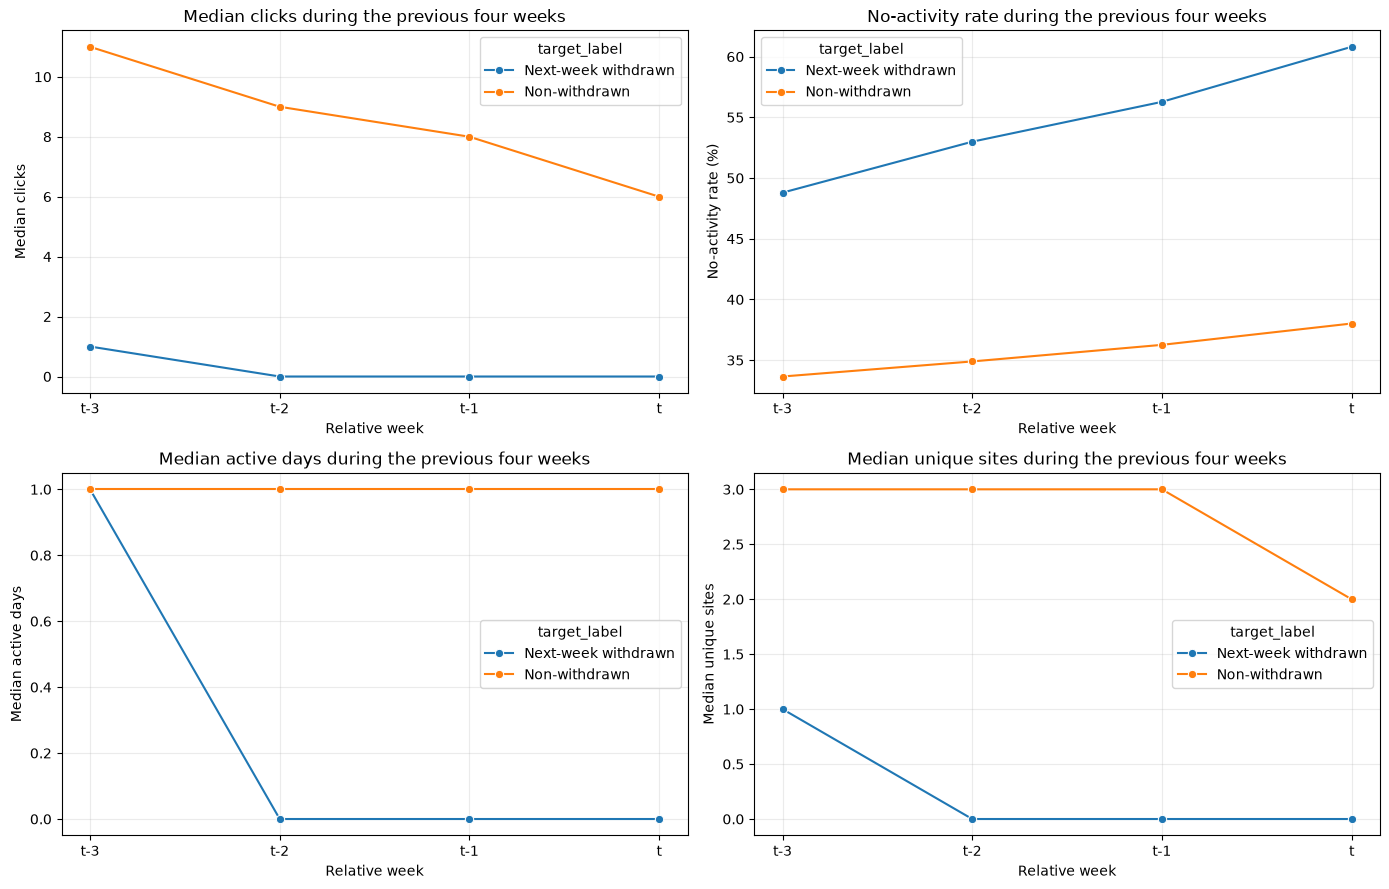

In [7]:
# 예측 시점 직전 4주 행동 흐름 생성
# t = 현재 예측 주차
# t-1, t-2, t-3 = 이전 주차

SEQUENCE_KEYS = [
    "code_module",
    "code_presentation",
    "id_student"
]

sequence_df = (
    eda[
        SEQUENCE_KEYS
        + [
            "prediction_week",
            TARGET_COL,
            "current_total_clicks",
            "current_active_days",
            "current_unique_sites",
            "current_no_activity"
        ]
    ]
    .sort_values(
        SEQUENCE_KEYS + ["prediction_week"]
    )
    .copy()
)

grouped = sequence_df.groupby(
    SEQUENCE_KEYS,
    observed=True,
    sort=False
)

# 4주가 연속으로 존재하는지 확인
sequence_df["week_at_lag_3"] = (
    grouped["prediction_week"].shift(3)
)

sequence_df["has_full_4_week_history"] = (
    sequence_df["prediction_week"]
    - sequence_df["week_at_lag_3"]
).eq(3)

# 현재 주와 이전 3주의 Feature 생성
sequence_features = [
    "current_total_clicks",
    "current_active_days",
    "current_unique_sites",
    "current_no_activity"
]

for lag in range(4):
    for feature in sequence_features:
        sequence_df[f"{feature}_lag_{lag}"] = (
            grouped[feature].shift(lag)
        )

valid_sequence = sequence_df.loc[
    sequence_df["has_full_4_week_history"]
].copy()

valid_sequence["target_label"] = np.where(
    valid_sequence[TARGET_COL].eq(1),
    "Next-week withdrawn",
    "Non-withdrawn"
)

print("4주 연속 Sequence 행 수:", len(valid_sequence))
print(
    "4주 Sequence 보유 비율:",
    f"{len(valid_sequence) / len(sequence_df):.2%}"
)
print(
    "Sequence Target 분포:"
)
print(valid_sequence[TARGET_COL].value_counts())

# 상대 주차별 행동 요약
sequence_summary_list = []

for lag in [3, 2, 1, 0]:
    temp = (
        valid_sequence
        .groupby(
            "target_label",
            as_index=False,
            observed=True
        )
        .agg(
            median_clicks=(
                f"current_total_clicks_lag_{lag}",
                "median"
            ),
            median_active_days=(
                f"current_active_days_lag_{lag}",
                "median"
            ),
            median_unique_sites=(
                f"current_unique_sites_lag_{lag}",
                "median"
            ),
            no_activity_rate=(
                f"current_no_activity_lag_{lag}",
                "mean"
            )
        )
    )

    temp["relative_week"] = (
        "t" if lag == 0 else f"t-{lag}"
    )

    temp["no_activity_rate_pct"] = (
        temp["no_activity_rate"] * 100
    )

    sequence_summary_list.append(temp)

sequence_trajectory = pd.concat(
    sequence_summary_list,
    ignore_index=True
)

relative_order = ["t-3", "t-2", "t-1", "t"]

sequence_trajectory["relative_week"] = pd.Categorical(
    sequence_trajectory["relative_week"],
    categories=relative_order,
    ordered=True
)

sequence_trajectory = sequence_trajectory.sort_values(
    ["relative_week", "target_label"]
)

display(sequence_trajectory.round(2))

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9)
)

plot_specs = [
    (
        "median_clicks",
        "Median clicks during the previous four weeks",
        "Median clicks"
    ),
    (
        "no_activity_rate_pct",
        "No-activity rate during the previous four weeks",
        "No-activity rate (%)"
    ),
    (
        "median_active_days",
        "Median active days during the previous four weeks",
        "Median active days"
    ),
    (
        "median_unique_sites",
        "Median unique sites during the previous four weeks",
        "Median unique sites"
    )
]

for ax, (column, title, ylabel) in zip(
    axes.flat,
    plot_specs
):
    sns.lineplot(
        data=sequence_trajectory,
        x="relative_week",
        y=column,
        hue="target_label",
        marker="o",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Relative week")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 최근 4주 행동 변화와 GRU 적용 근거

다음 주 이탈 예정자는 예측 시점 2~3주 전부터 클릭 수, 활동일,
이용 콘텐츠 수가 급격히 감소했으며 무활동 비율은 예측 시점에
가까워질수록 증가했다.

이는 한 시점의 Feature만 사용하는 것보다 최근 여러 주의 행동 순서를
함께 학습하는 GRU가 이탈 직전의 활동 감소 패턴을 포착할 가능성이
있음을 보여준다.

단, 4주의 관찰 기록이 모두 존재하는 행만 사용하면 초기 1~3주 예측
데이터가 제외된다. 초기 이탈이 가장 많으므로 실제 GRU 학습에서는
초기 주차를 제거하지 않고 부족한 과거 시점을 Padding하고 Masking한다.

In [8]:
# GRU 후보 Feature 품질 확인

gru_quality_features = [
    "current_total_clicks",
    "current_active_days",
    "current_unique_sites",
    "current_activity_type_count",
    "current_has_vle_record",
    "current_no_activity",
    "previous_total_clicks",
    "click_change",
    "click_change_rate",
    "weeks_since_last_activity",
    "vle_cum_total_clicks",
    "vle_cum_active_days",
    "vle_cum_unique_sites",
    "cum_unique_site_week_count",
    "cum_forumng_clicks",
    "cum_quiz_clicks",
    "cum_oucontent_clicks",
    "cum_resource_clicks",
    "cum_other_clicks",
    "assessment_due_count",
    "assessment_submitted_due_count",
    "assessment_missing_due_count",
    "assessment_late_count",
    "assessment_submission_rate",
    "assessment_mean_score",
]

quality_rows = []

for col in gru_quality_features:
    values = pd.to_numeric(
        eda[col],
        errors="coerce"
    )

    non_missing_values = values.dropna()

    quality_rows.append({
        "feature": col,
        "missing_count": values.isna().sum(),
        "missing_rate_pct": (
            values.isna().mean() * 100
        ),
        "infinite_count": np.isinf(
            non_missing_values
        ).sum(),
        "zero_rate_pct": (
            non_missing_values.eq(0).mean() * 100
            if len(non_missing_values) > 0
            else np.nan
        )
    })

quality_summary = (
    pd.DataFrame(quality_rows)
    .sort_values(
        ["missing_rate_pct", "zero_rate_pct"],
        ascending=False
    )
)

display(quality_summary.round(2))

# 기존 누적 고유 콘텐츠 Feature 이상 여부 확인
unique_site_problem = (
    eda["vle_cum_unique_sites"].isna()
    & eda["vle_cum_total_clicks"].gt(0)
)

print(
    "누적 클릭이 있지만 "
    "vle_cum_unique_sites가 결측인 행:",
    unique_site_problem.sum()
)

print(
    "vle_cum_unique_sites 전체 결측:",
    eda["vle_cum_unique_sites"].isna().sum()
)

print(
    "대체 Feature cum_unique_site_week_count 결측:",
    eda["cum_unique_site_week_count"].isna().sum()
)

,feature,missing_count,missing_rate_pct,infinite_count,zero_rate_pct
12,vle_cum_unique_sites,514058,57.44,0,0.00
24,assessment_mean_score,148532,16.60,0,0.12
23,assessment_submission_rate,82481,9.22,0,8.11
21,assessment_missing_due_count,0,0.00,0,68.45
5,current_no_activity,0,0.00,0,63.69
9,weeks_since_last_activity,0,0.00,0,63.69
22,assessment_late_count,0,0.00,0,59.96
8,click_change_rate,0,0.00,0,38.36
6,previous_total_clicks,0,0.00,0,37.38
15,cum_quiz_clicks,0,0.00,0,36.74


누적 클릭이 있지만 vle_cum_unique_sites가 결측인 행: 484708
vle_cum_unique_sites 전체 결측: 514058
대체 Feature cum_unique_site_week_count 결측: 0


### 누적 콘텐츠 이용 Feature 품질 점검

`vle_cum_unique_sites`는 전체 895,005건 중 514,058건이 결측이었다.
특히 누적 클릭이 존재하지만 해당 값이 결측인 경우가 484,708건이므로,
이를 실제 콘텐츠 미이용을 의미하는 0으로 대체할 수 없다.

따라서 GRU 입력에서는 `vle_cum_unique_sites`를 제외한다.
대신 결측이 없는 `current_unique_sites`의 주간 Sequence와
`cum_unique_site_week_count`를 콘텐츠 이용 범위 지표로 활용한다.

단, `cum_unique_site_week_count`는 주차별 고유 콘텐츠 수의 누적값이므로
전체 기간의 완전한 고유 콘텐츠 수와는 의미가 다르다.

,target_label,activity_type,mean_clicks,usage_rate_pct,click_share_pct
0,Next-week withdrawn,forumng,3.42,18.84,19.53
1,Next-week withdrawn,other,5.92,41.89,33.76
2,Next-week withdrawn,oucontent,4.36,22.18,24.88
3,Next-week withdrawn,quiz,3.09,8.44,17.60
4,Next-week withdrawn,resource,0.74,16.97,4.23
5,Non-withdrawn,forumng,8.39,36.09,20.07
6,Non-withdrawn,other,12.69,63.28,30.36
7,Non-withdrawn,oucontent,11.99,37.64,28.69
8,Non-withdrawn,quiz,7.65,15.04,18.29
9,Non-withdrawn,resource,1.08,26.40,2.59


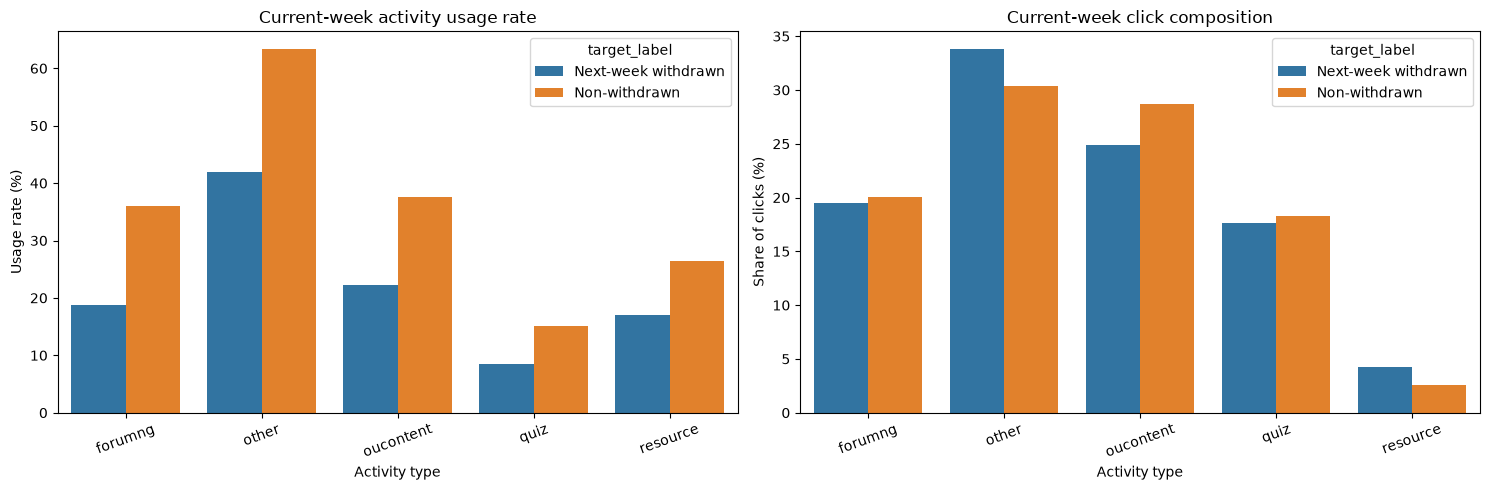

In [9]:
# 다음 주 이탈 여부에 따른 현재 주 활동 유형 비교

CURRENT_ACTIVITY_COLS = [
    "current_forumng_clicks",
    "current_oucontent_clicks",
    "current_quiz_clicks",
    "current_resource_clicks",
    "current_other_clicks",
]

activity_eda = pd.read_csv(
    DATA_PATH,
    usecols=[
        "code_module",
        "code_presentation",
        "id_student",
        "prediction_week",
        TARGET_COL,
        *CURRENT_ACTIVITY_COLS,
    ],
    low_memory=False
)

activity_eda["target_label"] = np.where(
    activity_eda[TARGET_COL].eq(1),
    "Next-week withdrawn",
    "Non-withdrawn"
)

activity_long = activity_eda.melt(
    id_vars=[
        "prediction_week",
        "target_label"
    ],
    value_vars=CURRENT_ACTIVITY_COLS,
    var_name="activity_type",
    value_name="clicks"
)

activity_long["activity_type"] = (
    activity_long["activity_type"]
    .str.replace("current_", "", regex=False)
    .str.replace("_clicks", "", regex=False)
)

activity_summary = (
    activity_long
    .groupby(
        ["target_label", "activity_type"],
        as_index=False,
        observed=True
    )
    .agg(
        total_clicks=("clicks", "sum"),
        mean_clicks=("clicks", "mean"),
        usage_rate=("clicks", lambda x: x.gt(0).mean())
    )
)

activity_summary["usage_rate_pct"] = (
    activity_summary["usage_rate"] * 100
)

activity_summary["click_share_pct"] = (
    activity_summary["total_clicks"]
    / activity_summary.groupby(
        "target_label",
        observed=True
    )["total_clicks"].transform("sum")
    * 100
)

display(
    activity_summary[
        [
            "target_label",
            "activity_type",
            "mean_clicks",
            "usage_rate_pct",
            "click_share_pct"
        ]
    ].round(2)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

sns.barplot(
    data=activity_summary,
    x="activity_type",
    y="usage_rate_pct",
    hue="target_label",
    ax=axes[0]
)
axes[0].set_title("Current-week activity usage rate")
axes[0].set_xlabel("Activity type")
axes[0].set_ylabel("Usage rate (%)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=activity_summary,
    x="activity_type",
    y="click_share_pct",
    hue="target_label",
    ax=axes[1]
)
axes[1].set_title("Current-week click composition")
axes[1].set_xlabel("Activity type")
axes[1].set_ylabel("Share of clicks (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 활동 유형별 차이

다음 주 이탈 예정자는 포럼, 학습 콘텐츠, 퀴즈, 자료 등 모든 활동
유형에서 비이탈자보다 이용률과 평균 클릭 수가 낮았다.

반면 전체 클릭 중 각 활동 유형이 차지하는 구성비 차이는 상대적으로
크지 않았다. 따라서 이탈 위험은 특정 콘텐츠 유형에 대한 선호 차이보다
전반적인 학습 참여 감소로 해석하는 것이 적절하다.

유지 활동은 모든 위험 학생에게 동일한 콘텐츠를 제공하기보다,
학생별로 과목·주차 평균 대비 가장 크게 감소한 활동 유형을 찾아
포럼 재참여, 학습자료 재접속, 퀴즈 수행 등을 차등 제안한다.

,prediction_week,target_label,student_course_count,total_due,total_submitted,total_missing,total_late,known_score_count,median_score,submission_rate_pct,missing_due_rate_pct,late_rate_pct
0,1,Next-week withdrawn,1068,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN
1,1,Non-withdrawn,27950,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN
2,2,Next-week withdrawn,214,9.0,4.0,5.0,0.0,4,74.50,44.44,55.56,0.00
3,2,Non-withdrawn,27770,1278.0,1020.0,258.0,19.0,1019,73.00,79.81,20.19,1.86
4,3,Next-week withdrawn,360,244.0,51.0,193.0,33.0,50,40.00,20.90,79.10,64.71
5,3,Non-withdrawn,27441,15505.0,11298.0,4207.0,1495.0,11294,76.00,72.87,27.13,13.23
6,4,Next-week withdrawn,303,280.0,144.0,136.0,102.0,142,60.00,51.43,48.57,70.83
7,4,Non-withdrawn,27146,23320.0,20193.0,3127.0,4955.0,19310,77.00,86.59,13.41,24.54
14,8,Next-week withdrawn,230,489.0,199.0,290.0,71.0,147,69.00,40.70,59.30,35.68
15,8,Non-withdrawn,26207,51744.0,40846.0,10900.0,9023.0,21846,78.00,78.94,21.07,22.09


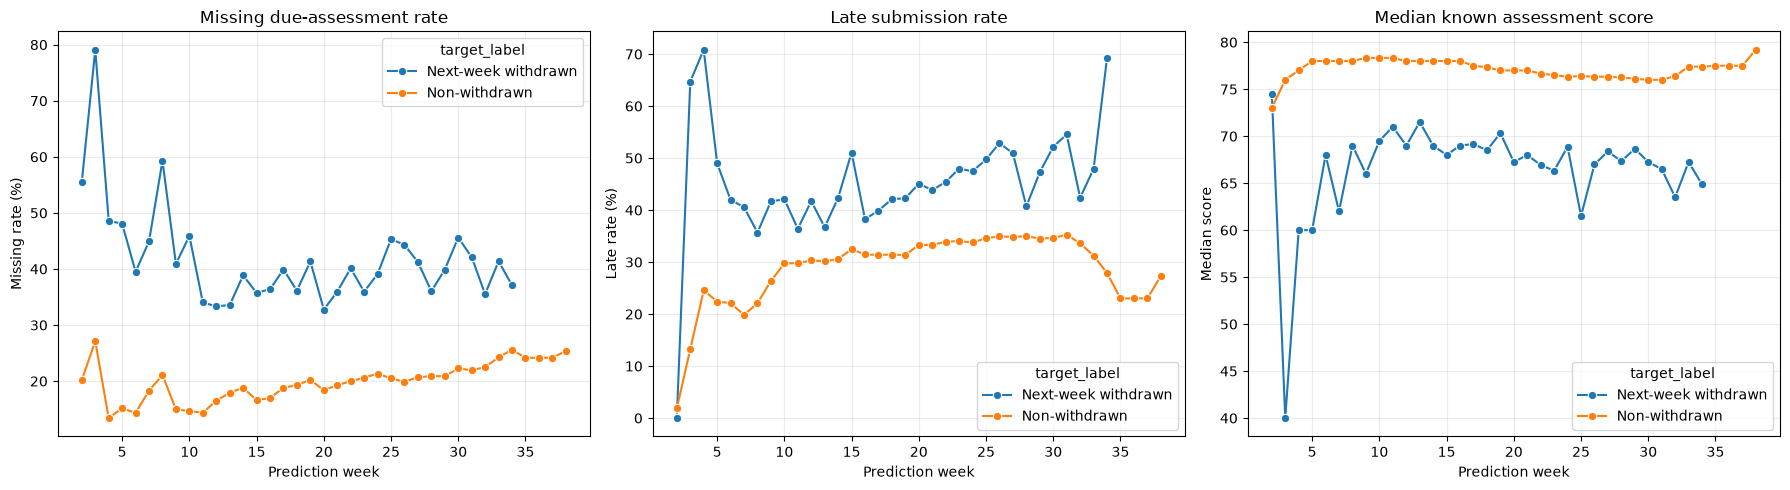

In [10]:
# 활동 유형 EDA 임시 데이터 메모리 정리
import gc

del activity_long
del activity_eda
gc.collect()


# 다음 주 이탈 여부에 따른 평가 행동 비교

assessment_eda = eda[
    [
        "prediction_week",
        TARGET_COL,
        "assessment_due_count",
        "assessment_submitted_due_count",
        "assessment_missing_due_count",
        "assessment_late_count",
        "assessment_mean_score",
    ]
].copy()

assessment_eda["target_label"] = np.where(
    assessment_eda[TARGET_COL].eq(1),
    "Next-week withdrawn",
    "Non-withdrawn"
)

weekly_assessment = (
    assessment_eda
    .groupby(
        ["prediction_week", "target_label"],
        as_index=False,
        observed=True
    )
    .agg(
        student_course_count=("target_label", "size"),
        total_due=("assessment_due_count", "sum"),
        total_submitted=(
            "assessment_submitted_due_count",
            "sum"
        ),
        total_missing=(
            "assessment_missing_due_count",
            "sum"
        ),
        total_late=("assessment_late_count", "sum"),
        known_score_count=(
            "assessment_mean_score",
            "count"
        ),
        median_score=(
            "assessment_mean_score",
            "median"
        )
    )
)

weekly_assessment["submission_rate_pct"] = np.where(
    weekly_assessment["total_due"].gt(0),
    weekly_assessment["total_submitted"]
    / weekly_assessment["total_due"]
    * 100,
    np.nan
)

weekly_assessment["missing_due_rate_pct"] = np.where(
    weekly_assessment["total_due"].gt(0),
    weekly_assessment["total_missing"]
    / weekly_assessment["total_due"]
    * 100,
    np.nan
)

weekly_assessment["late_rate_pct"] = np.where(
    weekly_assessment["total_submitted"].gt(0),
    weekly_assessment["total_late"]
    / weekly_assessment["total_submitted"]
    * 100,
    np.nan
)

display(
    weekly_assessment.loc[
        weekly_assessment["prediction_week"].isin(
            [1, 2, 3, 4, 8, 12, 16, 20]
        )
    ].round(2)
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

sns.lineplot(
    data=weekly_assessment,
    x="prediction_week",
    y="missing_due_rate_pct",
    hue="target_label",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Missing due-assessment rate")
axes[0].set_ylabel("Missing rate (%)")

sns.lineplot(
    data=weekly_assessment,
    x="prediction_week",
    y="late_rate_pct",
    hue="target_label",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Late submission rate")
axes[1].set_ylabel("Late rate (%)")

sns.lineplot(
    data=weekly_assessment,
    x="prediction_week",
    y="median_score",
    hue="target_label",
    marker="o",
    ax=axes[2]
)
axes[2].set_title("Median known assessment score")
axes[2].set_ylabel("Median score")

for ax in axes:
    ax.set_xlabel("Prediction week")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 평가 행동 차이

다음 주 이탈 예정자는 비이탈자보다 마감된 평가의 미제출률과
지각 제출률이 높았으며, 확인 가능한 평가 점수도 더 낮았다.

따라서 학습활동 감소뿐 아니라 평가 미제출, 지각 제출, 낮은 점수 역시
다음 주 이탈 위험을 설명하는 주요 행동 신호로 활용할 수 있다.

단, 과정 초기에는 마감된 평가가 적어 비율 변동이 크므로,
평가 Feature는 평가 일정이 존재하는 경우에 한해 해석해야 한다.

OOF 데이터 크기: (895005, 6)
OOF 키 중복: 0
OOF 전체 결측: 0
OOF Target 분포:
target_next_week_withdrawn
0    888333
1      6672
Name: count, dtype: int64

===== CatBoost OOF 기준 성능 =====
PR-AUC: 0.094775
Brier Score: 0.007045
Recall@Top20%: 71.1331%
Precision@Top20%: 2.6514%
Top20% Threshold: 0.009791


,risk_decile,row_count,positive_count,mean_predicted_probability,observed_withdrawal_rate,mean_predicted_probability_pct,observed_withdrawal_rate_pct
0,1,89501,20,0.0004,0.0002,0.0382,0.0223
1,2,89500,53,0.0009,0.0006,0.0860,0.0592
2,3,89501,75,0.0014,0.0008,0.1369,0.0838
3,4,89500,122,0.0020,0.0014,0.1974,0.1363
4,5,89501,187,0.0027,0.0021,0.2747,0.2089
5,6,89500,270,0.0038,0.0030,0.3817,0.3017
6,7,89500,469,0.0054,0.0052,0.5375,0.5240
7,8,89501,730,0.0079,0.0082,0.7929,0.8156
8,9,89500,1260,0.0131,0.0141,1.3072,1.4078
9,10,89501,3486,0.0374,0.0389,3.7373,3.8949


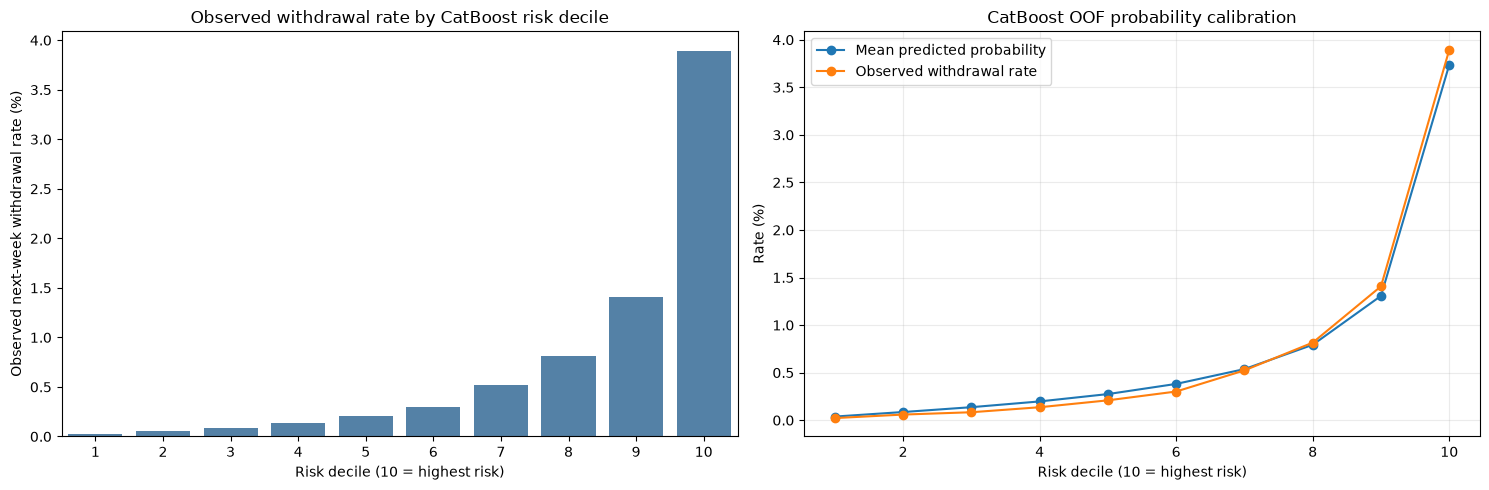

In [11]:
# 기존 CatBoost OOF 예측 검증 및 기준 성능 확인

import gc
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss
)

del assessment_eda
gc.collect()

oof = pd.read_csv(
    OOF_PATH,
    low_memory=False
)

OOF_KEY_COLS = [
    "code_module",
    "code_presentation",
    "id_student",
    "prediction_week"
]

OOF_TARGET = "target_next_week_withdrawn"
OOF_PROBABILITY = "catboost_oof_probability"

print("OOF 데이터 크기:", oof.shape)
print(
    "OOF 키 중복:",
    oof.duplicated(OOF_KEY_COLS).sum()
)
print(
    "OOF 전체 결측:",
    oof.isna().sum().sum()
)
print(
    "OOF Target 분포:"
)
print(oof[OOF_TARGET].value_counts())

y_true = oof[OOF_TARGET].to_numpy()
y_probability = oof[OOF_PROBABILITY].to_numpy()

# PR-AUC와 Brier Score
pr_auc = average_precision_score(
    y_true,
    y_probability
)

brier = brier_score_loss(
    y_true,
    y_probability
)

# 위험도 상위 20% 기준 성능
top_20_count = int(np.ceil(len(oof) * 0.20))

top_20_index = np.argsort(
    -y_probability,
    kind="stable"
)[:top_20_count]

top_20_true_positive = y_true[
    top_20_index
].sum()

recall_at_20 = (
    top_20_true_positive
    / y_true.sum()
)

precision_at_20 = (
    top_20_true_positive
    / top_20_count
)

top_20_threshold = y_probability[
    top_20_index
].min()

print("\n===== CatBoost OOF 기준 성능 =====")
print(f"PR-AUC: {pr_auc:.6f}")
print(f"Brier Score: {brier:.6f}")
print(f"Recall@Top20%: {recall_at_20:.4%}")
print(f"Precision@Top20%: {precision_at_20:.4%}")
print(f"Top20% Threshold: {top_20_threshold:.6f}")

# 위험도 10분위별 예측 확률과 실제 이탈률
oof["risk_decile"] = pd.qcut(
    oof[OOF_PROBABILITY].rank(method="first"),
    q=10,
    labels=range(1, 11)
)

calibration_summary = (
    oof
    .groupby(
        "risk_decile",
        as_index=False,
        observed=True
    )
    .agg(
        row_count=(OOF_TARGET, "size"),
        positive_count=(OOF_TARGET, "sum"),
        mean_predicted_probability=(
            OOF_PROBABILITY,
            "mean"
        ),
        observed_withdrawal_rate=(
            OOF_TARGET,
            "mean"
        )
    )
)

calibration_summary[
    "mean_predicted_probability_pct"
] = (
    calibration_summary[
        "mean_predicted_probability"
    ] * 100
)

calibration_summary[
    "observed_withdrawal_rate_pct"
] = (
    calibration_summary[
        "observed_withdrawal_rate"
    ] * 100
)

display(calibration_summary.round(4))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

# 위험 분위별 실제 이탈률
sns.barplot(
    data=calibration_summary,
    x="risk_decile",
    y="observed_withdrawal_rate_pct",
    color="steelblue",
    ax=axes[0]
)
axes[0].set_title(
    "Observed withdrawal rate by CatBoost risk decile"
)
axes[0].set_xlabel(
    "Risk decile (10 = highest risk)"
)
axes[0].set_ylabel(
    "Observed next-week withdrawal rate (%)"
)

# 예측확률과 실제 발생률 비교
axes[1].plot(
    calibration_summary["risk_decile"],
    calibration_summary[
        "mean_predicted_probability_pct"
    ],
    marker="o",
    label="Mean predicted probability"
)

axes[1].plot(
    calibration_summary["risk_decile"],
    calibration_summary[
        "observed_withdrawal_rate_pct"
    ],
    marker="o",
    label="Observed withdrawal rate"
)

axes[1].set_title(
    "CatBoost OOF probability calibration"
)
axes[1].set_xlabel(
    "Risk decile (10 = highest risk)"
)
axes[1].set_ylabel("Rate (%)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Demo1 주간 EDA 최종 결론

### 1. 분석 목표

각 예측 주차까지 관찰된 학생의 학습행동을 이용하여 해당 학생이
바로 다음 주에 과목을 중도이탈할 위험을 예측한다.

- 분석 단위: 학생-과목-학기-예측 주차
- Target: 다음 주 `date_unregistration`이 발생하면 1
- 전체 데이터: 895,005건
- 다음 주 이탈: 6,672건
- 전체 다음 주 이탈률: 약 0.7455%

### 2. 주차별·과목별 이탈

1주차 행동으로 2주차 이탈을 예측하는 구간의 이탈자는 1,068명,
조건부 이탈률은 약 3.68%로 가장 높았다.

초기 이탈 위험이 가장 크지만 이후에도 이탈이 계속 발생하므로,
특정 한 주차만 예측하는 방식보다 매주 최신 행동을 반영해 다음 주
위험을 반복적으로 예측하는 조기경보 방식이 적절하다.

과목별로는 특히 CCC의 초기 위험이 높았으며, 이후 위험 패턴도
과목마다 다르게 나타났다. 따라서 예측 결과는 과목별로 구분하여
제공해야 한다.

### 3. 이탈 직전 학습행동

다음 주 이탈 예정자는 비이탈자보다 다음 행동이 뚜렷하게 낮았다.

- 현재 주 클릭 수
- 활동일 수
- 이용 콘텐츠 수
- 포럼·학습 콘텐츠·퀴즈·자료 이용률

또한 이탈 예정자는 예측 시점 2~3주 전부터 활동이 감소하고
무활동 비율이 증가했다. 이러한 시간 흐름은 최근 여러 주의 행동
Sequence를 학습하는 GRU 적용 근거가 된다.

### 4. 평가 행동

다음 주 이탈 예정자는 비이탈자보다 다음 특성을 보였다.

- 마감 평가 미제출률 증가
- 지각 제출률 증가
- 평가 점수 감소

따라서 VLE 활동뿐 아니라 평가 수행 정보도 이탈 위험을 설명하는
보조 신호로 활용할 수 있다.

### 5. 데이터 품질 및 GRU 처리 기준

`vle_cum_unique_sites`는 전체 895,005건 중 514,058건이 결측이었다.
특히 누적 클릭이 있지만 해당 값이 결측인 행이 484,708건이므로
0으로 대체할 수 없다.

GRU에서는 해당 Feature를 제외하고 다음 Feature를 활용한다.

- 현재 주 `current_unique_sites`
- 최근 주차의 `current_unique_sites` Sequence
- 결측이 없는 `cum_unique_site_week_count`

초기 1~3주 데이터는 완전한 4주 Sequence가 존재하지 않지만,
초기 이탈이 가장 많으므로 제거하지 않는다. 부족한 과거 시점은
Padding하고 Masking하여 전체 895,005건을 유지한다.

### 6. CatBoost 기준 성능

CatBoost OOF 기준 성능은 다음과 같다.

- PR-AUC: 0.094775
- Brier Score: 0.007045
- Recall@Top20%: 71.13%
- 최상위 위험 10% 포함 이탈자: 3,486명

위험 분위가 증가할수록 실제 다음 주 이탈률도 일관되게 증가했으며,
예측확률과 실제 발생률도 비교적 잘 일치했다.

### 7. GRU 평가 기준

GRU는 CatBoost와 동일한 학생 단위 분할 및 동일 Target을 사용하고,
다음 지표로 비교한다.

- PR-AUC
- Recall@Top20%
- Precision@Top20%
- Brier Score
- 위험 분위별 실제 이탈률

GRU 단독 성능뿐 아니라 CatBoost와 GRU의 예측 오류가 서로 다른지도
확인한다. 두 모델이 서로 다른 이탈자를 찾아낼 경우 확률 결합을
검토하고, 최종 선택된 예측확률에 Demo2의 Platt Scaling을 적용한다.